In [55]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import s3fs
import xarray as xr
import os
import pandas as pd

# Xarray dark mode hack
from IPython.display import HTML, display

display(HTML("""
<style>
    .xr-wrap {
        --xr-background-color-row-odd: rgba(100, 100, 100, 0.10) !important;
        --xr-background-color-row-even: rgba(30, 30, 30, 0.10) !important;
    }
</style>
"""))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
fs = s3fs.S3FileSystem(
    key=os.environ["AWS_ACCESS_KEY_ID"],
    secret=os.environ["AWS_SECRET_ACCESS_KEY"],
    client_kwargs={"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    config_kwargs={
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
                }
)

storage_options = {
    "client_kwargs": {"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    "config_kwargs": {
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
    },
}

In [57]:
dis = pd.read_csv('/Users/cjense/Downloads/dataverse_files/sector_D.csv')
dis['Date'] = pd.to_datetime(dis['Date'])

In [62]:
disZI = dis[['Date', 'ZACHARIAE_ISSTROM']]
disZI = disZI.loc[(disZI['Date'] > '2000-01-01') & (disZI['Date'] <= '2025-12-31')]
disZI

,Date,ZACHARIAE_ISSTROM
102,2000-02-15,10.143400
103,2000-03-15,10.315785
104,2000-04-15,10.500049
105,2000-05-15,10.678360
106,2000-06-15,10.862606
...,...,...
2959,2025-11-12,17.465826
2960,2025-11-24,17.243470
2961,2025-12-06,17.397650
2962,2025-12-18,17.406412


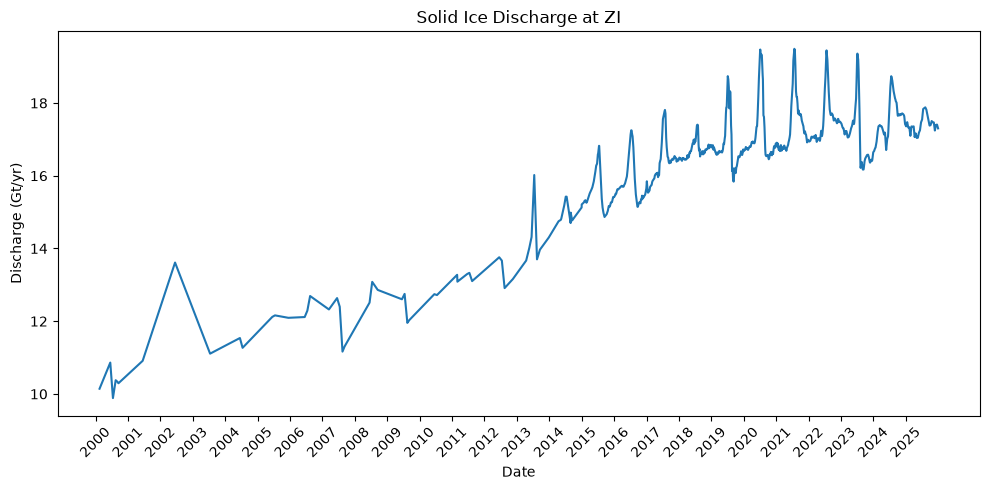

In [63]:
plt.subplots(figsize=(10,5))

plt.plot(disZI['Date'], disZI['ZACHARIAE_ISSTROM'])

years = pd.date_range(
    disZI['Date'].min().replace(month=1, day=1),
    disZI['Date'].max(),
    freq='YS'
)

plt.xticks(years, years.strftime('%Y'), rotation=45)
plt.ylabel('Discharge (Gt/yr)')
plt.xlabel('Date')
plt.title('Solid Ice Discharge at ZI')
plt.tight_layout()
plt.savefig('figures/discharge_ZI.png', dpi=300)
plt.show()

In [61]:
dis79N = dis[['Date', 'NIOGHALVFJERDSFJORDEN']]
dis79N = dis79N.loc[(dis79N['Date'] > '2000-01-01') & (dis79N['Date'] <= '2025-12-31')]
dis79N

,Date,NIOGHALVFJERDSFJORDEN
102,2000-02-15,12.188143
103,2000-03-15,12.299239
104,2000-04-15,12.417985
105,2000-05-15,12.532892
106,2000-06-15,12.651617
...,...,...
2959,2025-11-12,13.244141
2960,2025-11-24,13.144099
2961,2025-12-06,13.211903
2962,2025-12-18,13.250596


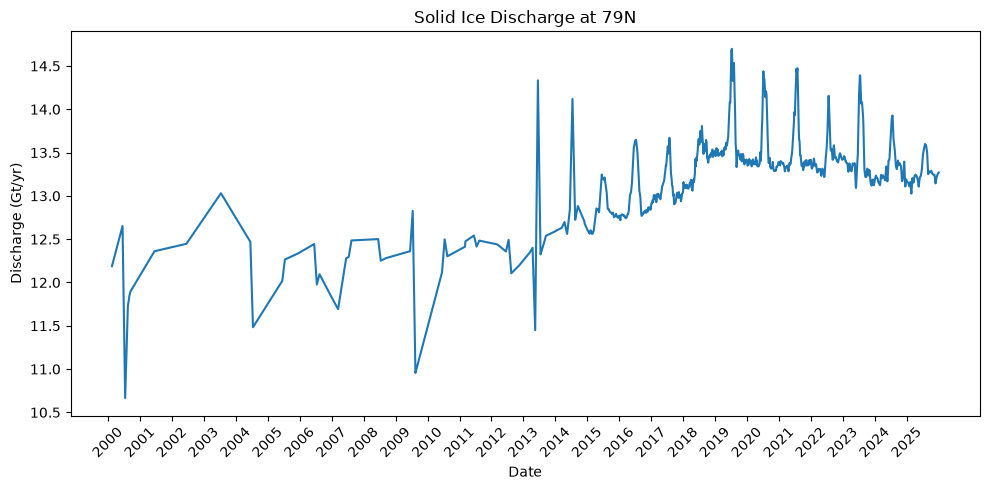

In [64]:
plt.subplots(figsize=(10,5))
plt.plot(dis79N['Date'], dis79N['NIOGHALVFJERDSFJORDEN'])

years = pd.date_range(
    dis79N['Date'].min().replace(month=1, day=1),
    dis79N['Date'].max(),
    freq='YS'
)

plt.xticks(years, years.strftime('%Y'), rotation=45)
plt.ylabel('Discharge (Gt/yr)')
plt.xlabel('Date')
plt.title('Solid Ice Discharge at 79N')
plt.tight_layout()
plt.savefig('figures/discharge_79N.png', dpi=300)
plt.show()

In [66]:
dis79N.to_parquet('s3://gaia/cjense/data/discharge/discharge_79N.parquet', storage_options=storage_options)
disZI.to_parquet('s3://gaia/cjense/data/discharge/discharge_ZI.parquet', storage_options=storage_options)